<center><font size=6> Bank Churn Prediction </font></center>

## Problem Statement

### Context

Businesses like banks which provide service have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

You as a Data scientist with the  bank need to  build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* isActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month. It can take two values
** 0=No ( Customer did not leave the bank )
** 1=Yes ( Customer left the bank )

## Importing necessary libraries

In [128]:
import pandas as pd  # Library for data manipulation and analysis.
import numpy as np   # Fundamental package for scientific computing.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

from imblearn.over_sampling import SMOTE  #For Over Sampling
from imblearn.under_sampling import RandomUnderSampler  #For Under Sampling

from sklearn.preprocessing import StandardScaler

# importing metrics
from sklearn.metrics import confusion_matrix,roc_curve,classification_report,recall_score

from sklearn.model_selection import train_test_split  # Function for splitting datasets for training and testing.

import time  # Module for time-related operations.
import random

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense   # for creating fully connected neural network layers.
from keras.layers import Dropout


# Library to avoid the warnings
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive

## Loading the dataset

In [129]:
drive.mount("/content/drive")

#Read the dataset
data = pd.read_csv(("/content/drive/MyDrive/Colab Notebooks/Project4-NN-BankChurn/Churn.csv"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Overview

In [130]:
data.shape

(10000, 14)

In [131]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Observations:
There are no null values


In [133]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


Min age is 18 years and Max is 92, and the median age is 44.

Balance column has outliers and is right skewed.



In [134]:
data['Exited'].unique()

array([1, 0])

In [135]:
data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

Observations:
The dataset is highly imbalanced looking at the "Exited" values.

There are 7963 existing customers, and 2037 Exited customers.

In [136]:
data.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [137]:
data.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [138]:
 data.select_dtypes('object')

,Surname,Geography,Gender
0,Hargrave,France,Female
1,Hill,Spain,Female
2,Onio,France,Female
3,Boni,France,Female
4,Mitchell,Spain,Female
...,...,...,...
9995,Obijiaku,France,Male
9996,Johnstone,France,Male
9997,Liu,France,Female
9998,Sabbatini,Germany,Male


Observations:

We can drop the following columns :

Row Number, Surname, CustomerId

In [139]:
data.duplicated().sum()

0

There are no Duplicate values

Drop the columns with unique values

In [140]:
data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [141]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [142]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


## Exploratory Data Analysis

### Univariate Analysis

In [143]:
#Function to draw histogram and box plot

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):

  #Create 2 subplots
  f2, (ax_box2, ax_hist2) = plt.subplots(
      nrows=2, # Number of plots of the subplot grid is 2
      sharex=True, #X axis will be shared between plots
      gridspec_kw = {"height_ratios": (0.25, 0.75)},
      figsize=figsize
  )

  sns.boxplot(
     data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
  ) #boxplot will be created and mean will be shown as *

  sns.histplot(
      data=data, x=feature, ax=ax_hist2, kde=kde, bins=bins, palette="winter"
  ) if bins else sns.histplot(
      data=data, x=feature, kde=kde, ax=ax_hist2
  ) #histogram
  ax_hist2.axvline(
      data[feature].mean(), color="green", linestyle="--"
  )#Add mean to the histogram
  ax_hist2.axvline(
      data[feature].median(), color="black", linestyle="-"
  )#Add median to the histogram


In [144]:
# Function to create labeled bar plots

def labeled_barplot(data, feature, perc=False, n=None):

  total = len(data[feature]) #Length of the column

  count = data[feature].nunique()

  if n is None:
    plt.figure(figsize=(count+1, 5))
  else:
    plt.figure(figsize=(n+1, 5))

  plt.xticks(rotation=90, fontsize=15)

  ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

  for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

  plt.show()  # show the plot

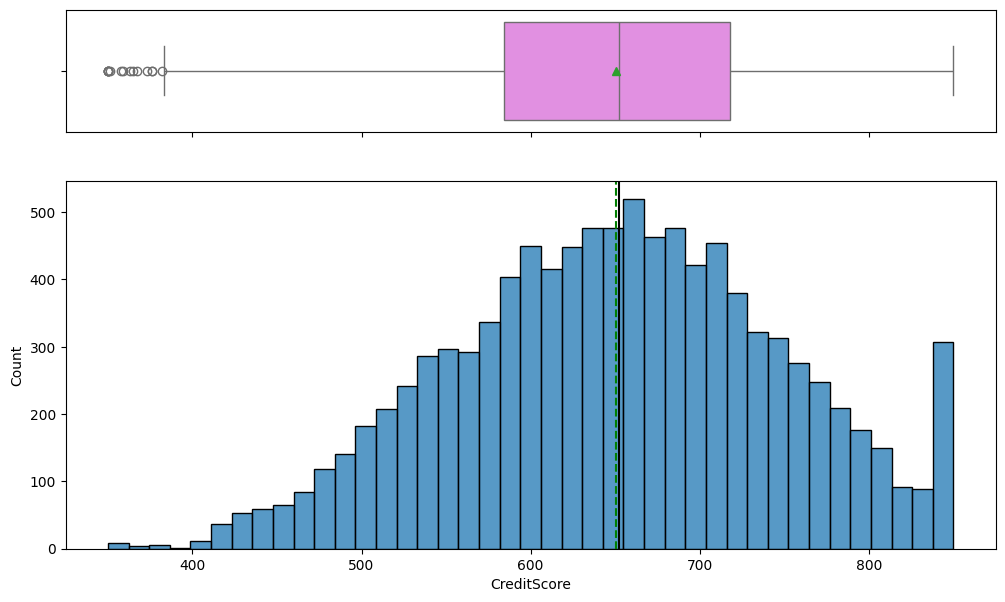

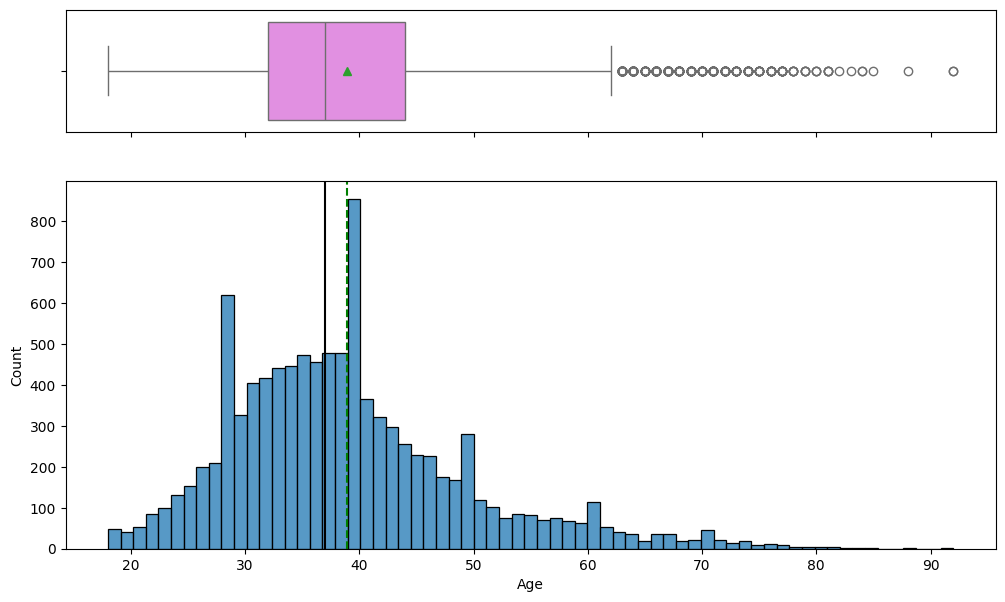

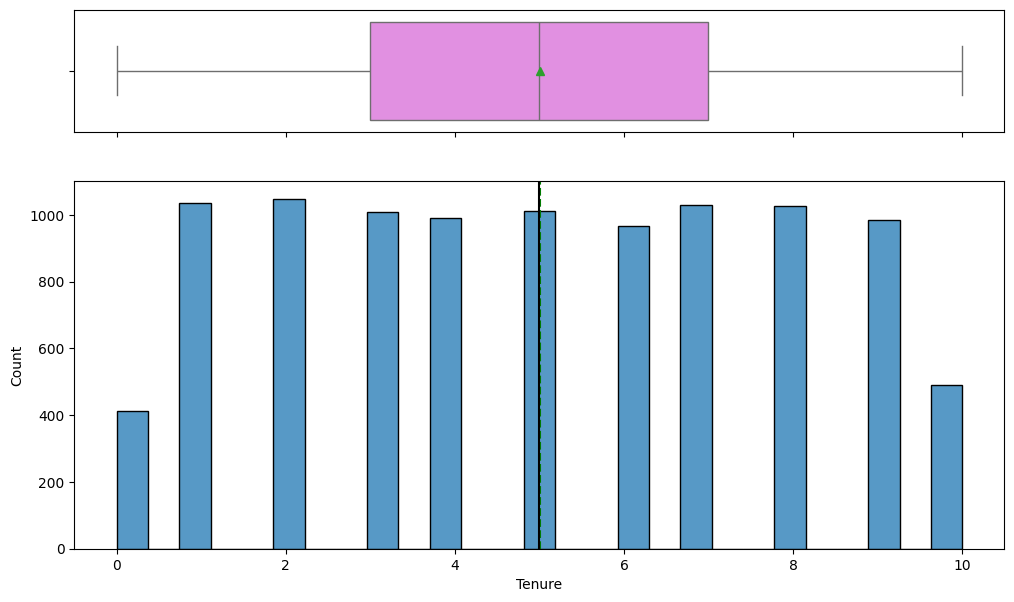

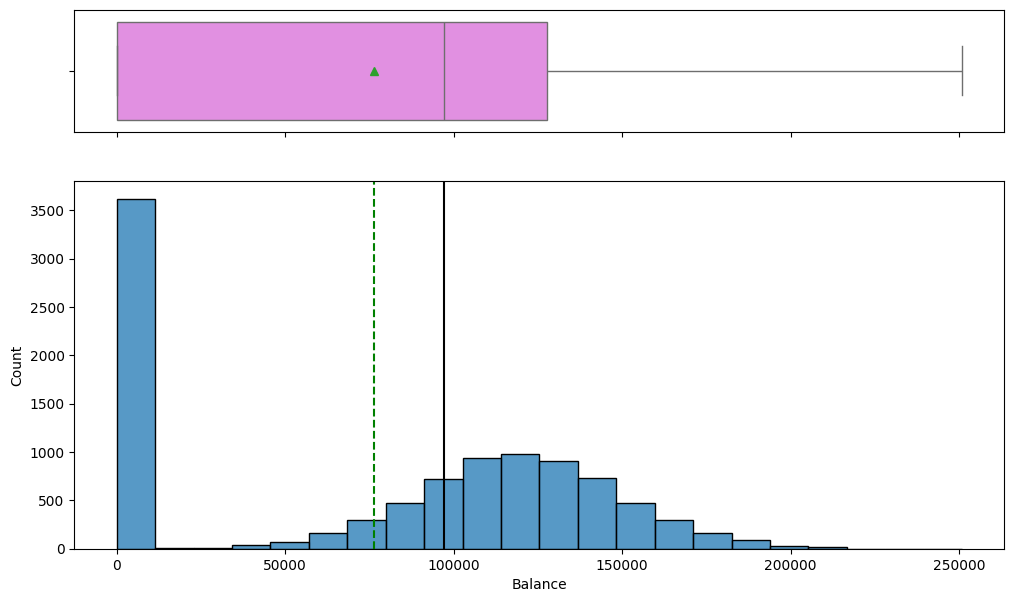

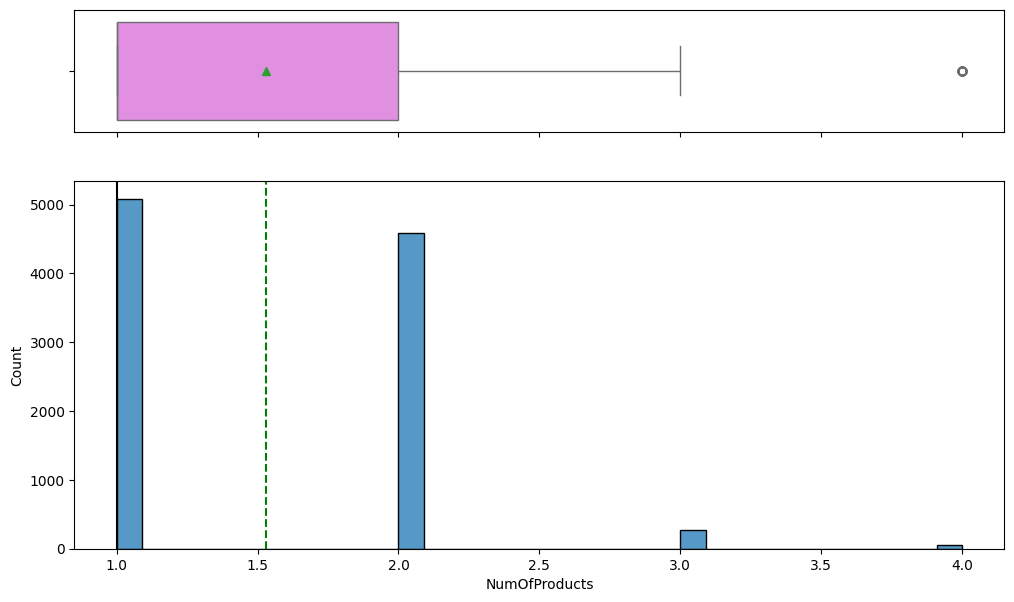

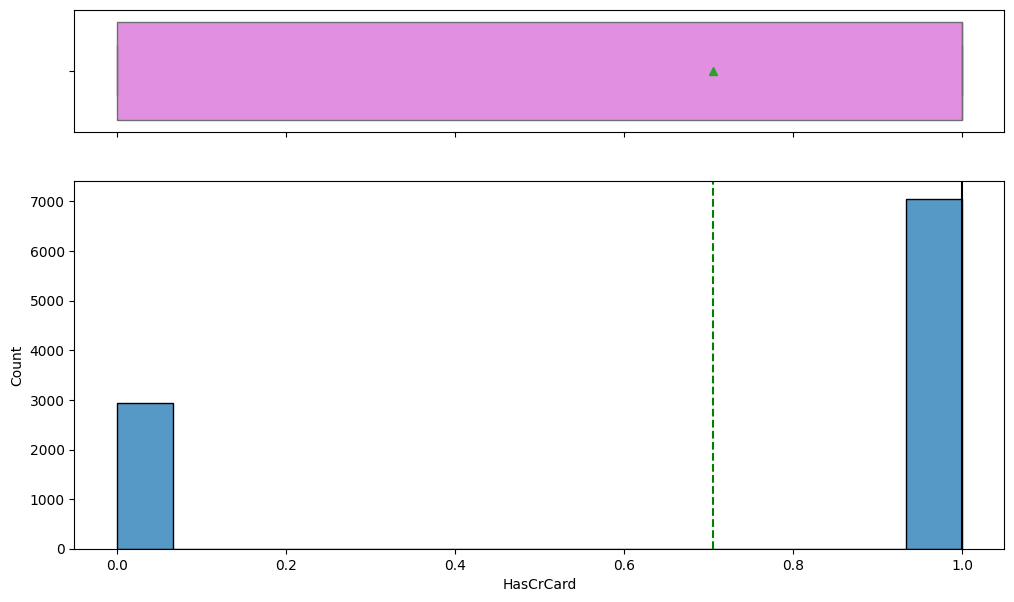

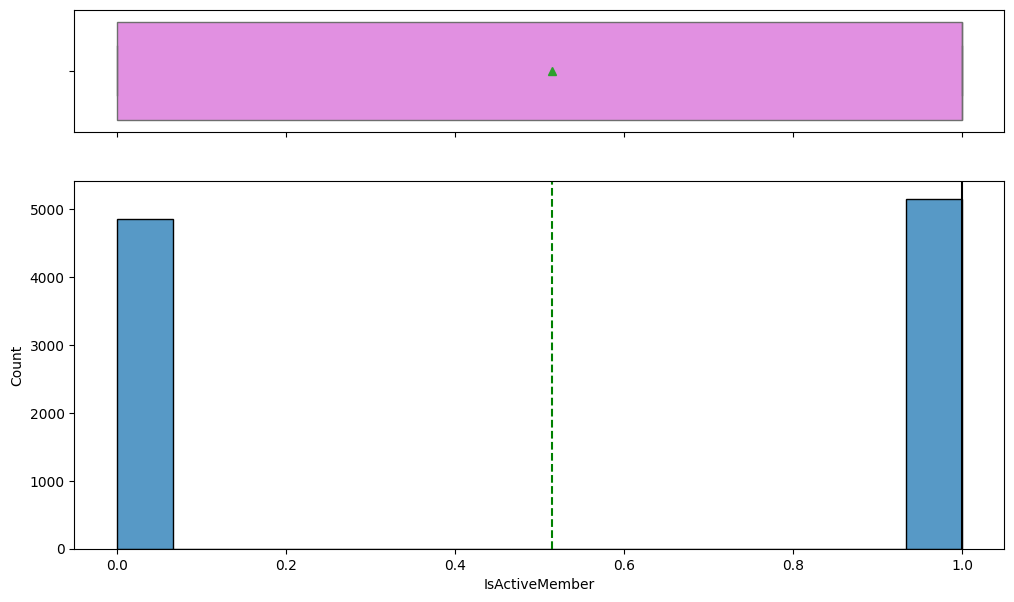

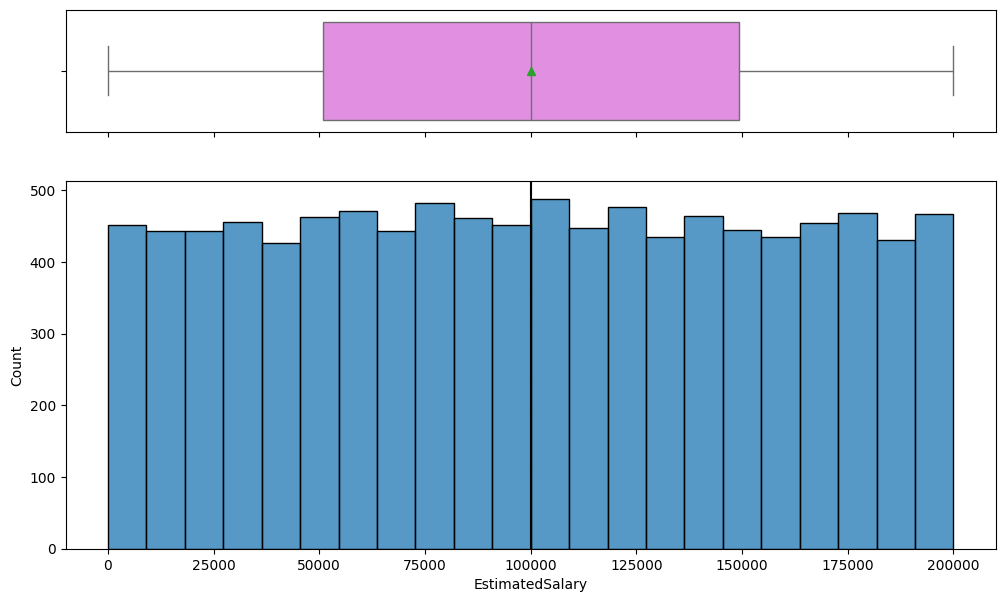

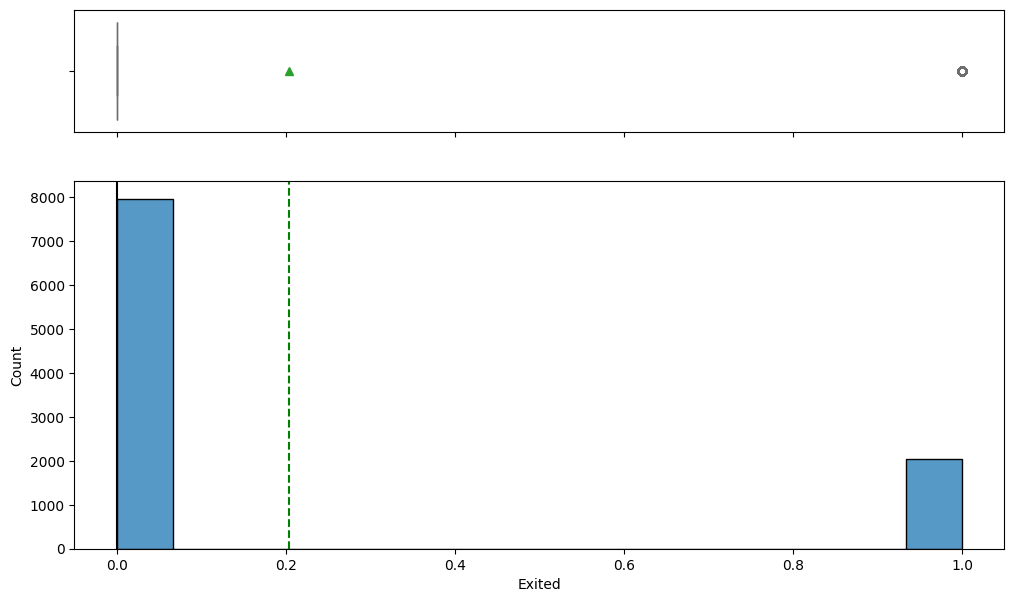

In [145]:
cols = data.select_dtypes(include=['float64', 'int64'])

for column in cols:
  histogram_boxplot(data, column)

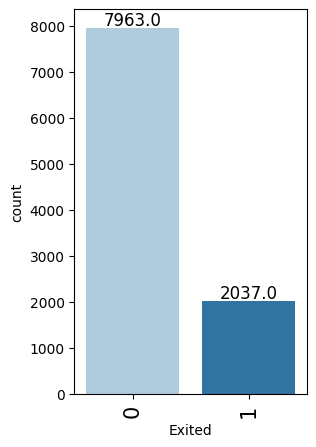

In [146]:
labeled_barplot(data, 'Exited')

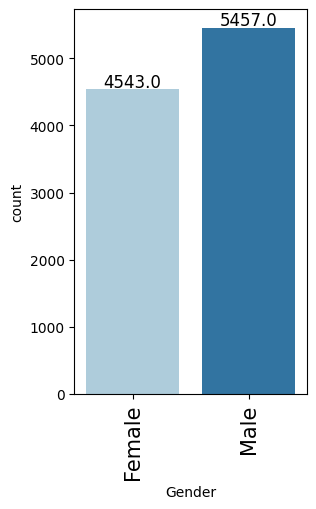

In [147]:
labeled_barplot(data, "Gender")

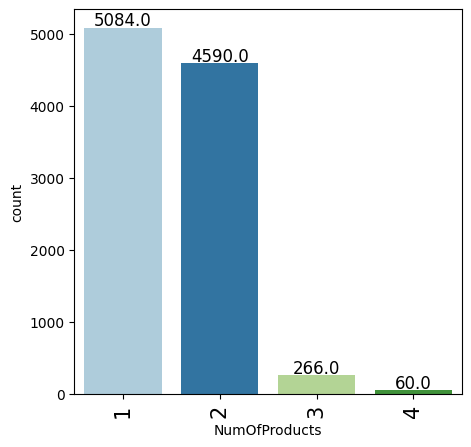

In [148]:
labeled_barplot(data, 'NumOfProducts')

Max number of products customers have is 2

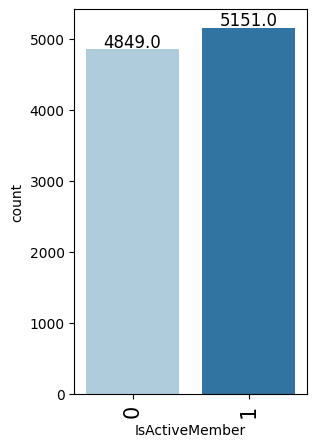

In [149]:
labeled_barplot(data, 'IsActiveMember')

### Bivariate Analysis

In [150]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 7))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

Exited     0     1    All
Age                      
All     7963  2037  10000
46       135    91    226
40       343    89    432
43       209    88    297
45       142    87    229
..       ...   ...    ...
79         4     0      4
78         5     0      5
77        10     0     10
76        11     0     11
75         9     0      9

[71 rows x 3 columns]
------------------------------------------------------------------------------------------------------------------------


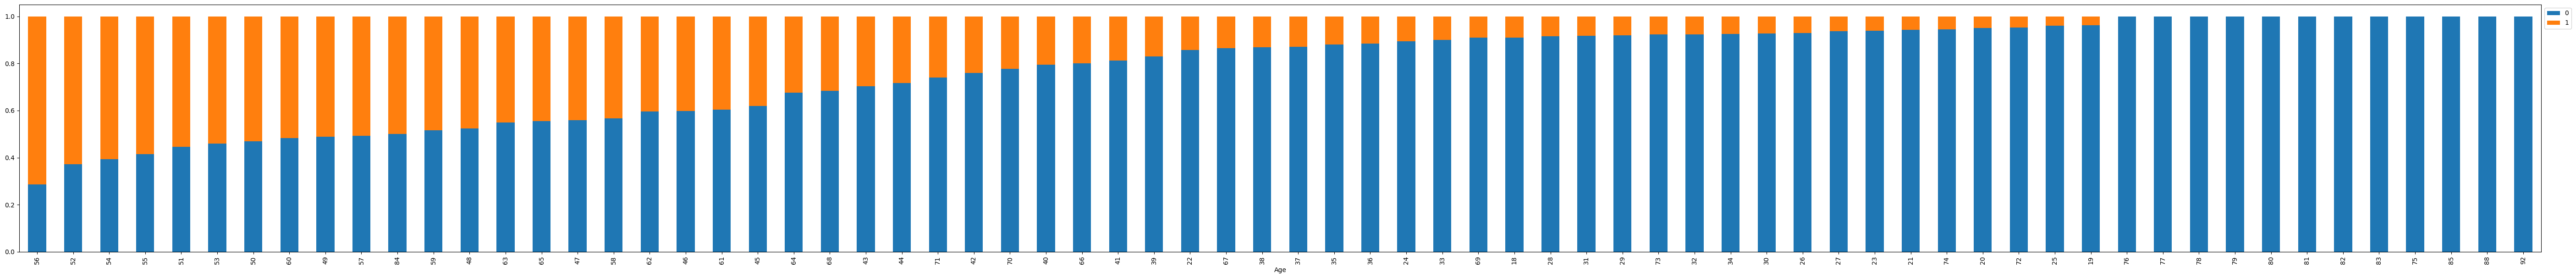

In [151]:
stacked_barplot(data, 'Age', 'Exited')

Exited     0     1    All
Gender                   
All     7963  2037  10000
Female  3404  1139   4543
Male    4559   898   5457
------------------------------------------------------------------------------------------------------------------------


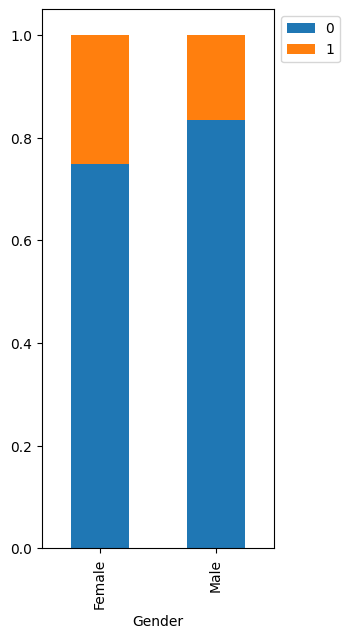

In [152]:
stacked_barplot(data, 'Gender', 'Exited')

Exited     0     1    All
Tenure                   
All     7963  2037  10000
1        803   232   1035
3        796   213   1009
9        771   213    984
5        803   209   1012
4        786   203    989
2        847   201   1048
8        828   197   1025
6        771   196    967
7        851   177   1028
10       389   101    490
0        318    95    413
------------------------------------------------------------------------------------------------------------------------


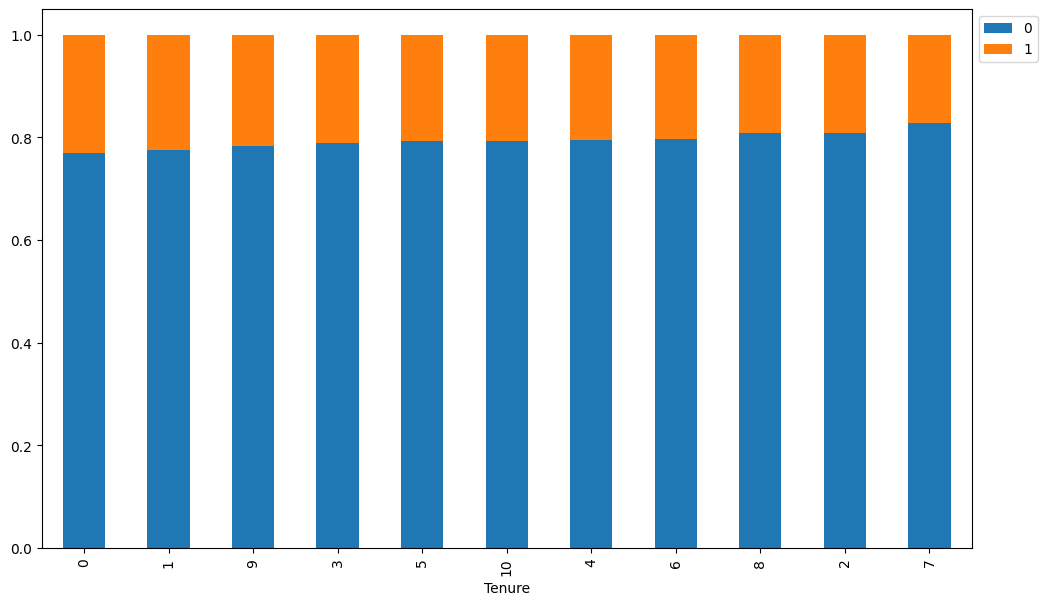

In [153]:
stacked_barplot(data, 'Tenure', 'Exited')

Exited        0     1    All
HasCrCard                   
All        7963  2037  10000
1          5631  1424   7055
0          2332   613   2945
------------------------------------------------------------------------------------------------------------------------


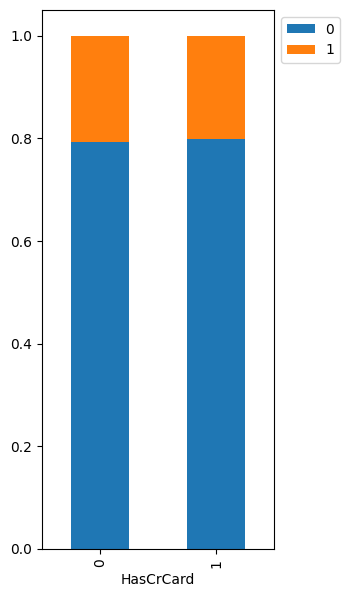

In [154]:
stacked_barplot(data, 'HasCrCard', 'Exited')

Exited             0     1    All
IsActiveMember                   
All             7963  2037  10000
0               3547  1302   4849
1               4416   735   5151
------------------------------------------------------------------------------------------------------------------------


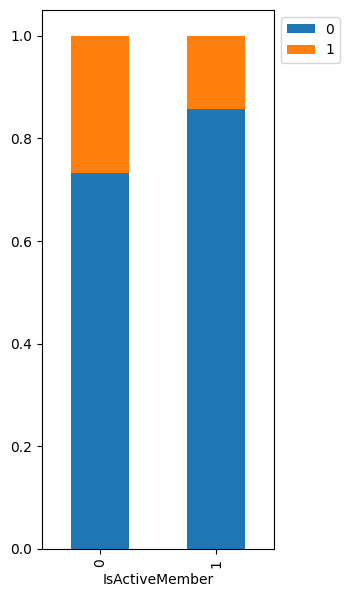

In [155]:
stacked_barplot(data, 'IsActiveMember', 'Exited')

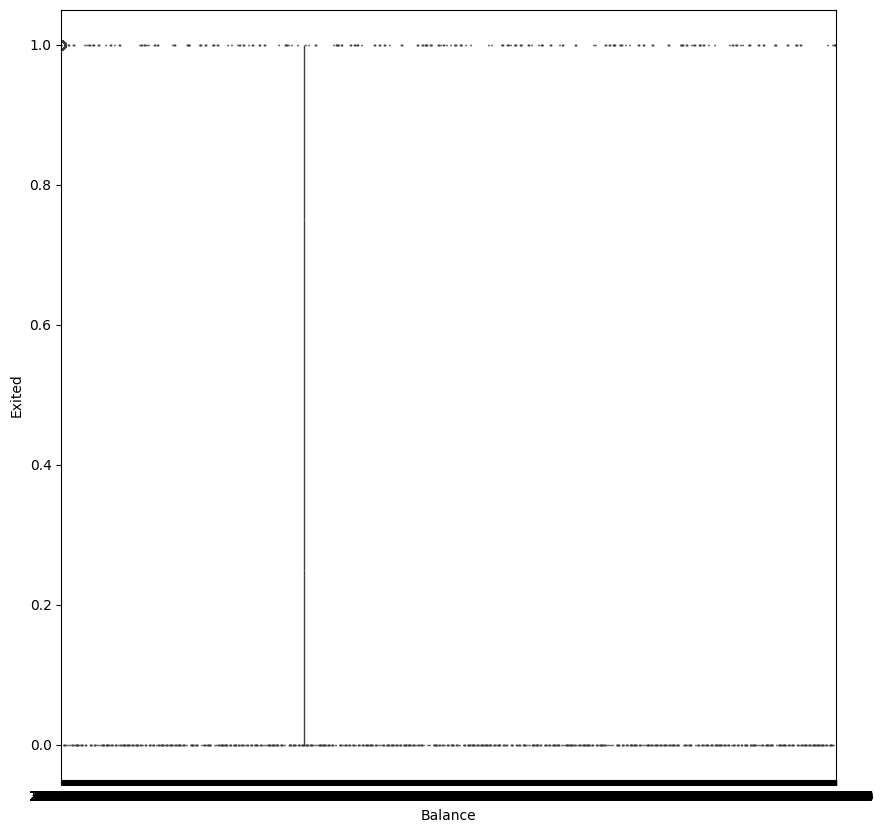

In [156]:
plt.figure(figsize=(10,10))
sns.boxplot(y='Exited',x='Balance',data=data)               ## Complete the code to plot the boxplot for Exited and Balance
plt.show()

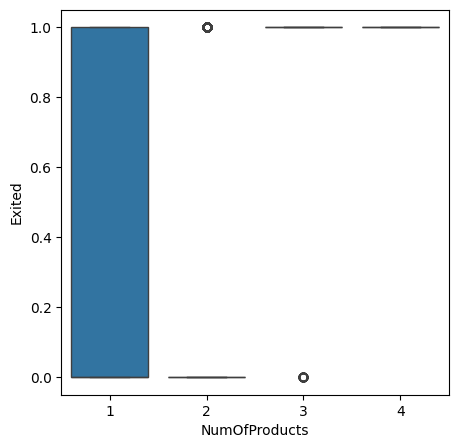

In [157]:
plt.figure(figsize=(5,5))
sns.boxplot(y='Exited',x='NumOfProducts',data=data)               ## Complete the code to plot the boxplot for Exited and Balance
plt.show()

Most of the customers exited had just 1 product

## Data Preprocessing

### Train-validation-test Split

In [158]:
#Separating predictors(X) and target(y)
X = data.drop(['Exited'], axis=1)
y = data['Exited']

Split the data into Train and Validation Dataset

Train data is 60%, Validation data is 20%, Test data is 20%


In [159]:
X_train, X_temp, y_train,  y_temp = train_test_split(X, y, train_size=0.6, random_state=42, stratify=y, shuffle=True)

In [160]:
X_val, X_test, y_val,  y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=42, stratify=y_temp, shuffle=True)

In [161]:
print(X_train.shape, X_val.shape, X_test.shape)

(6000, 10) (2000, 10) (2000, 10)


Target value is equally distributed across datasets

In [162]:
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Exited
0    0.796333
1    0.203667
Name: proportion, dtype: float64
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


### Dummy Variable Creation

In [163]:
#Create dummy variables for X_train
X_train = pd.get_dummies(X_train, columns=["Geography", "Gender"], drop_first=True)

In [164]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
6851,527,39,9,96748.89,2,1,0,94711.43,True,False,False
7026,677,27,2,0.00,2,0,1,114685.92,False,False,False
5705,628,40,5,181768.32,2,1,1,129107.97,True,False,True
9058,470,48,6,140576.11,1,1,1,116971.05,False,True,False
9415,768,43,2,129264.05,2,0,0,19150.14,True,False,False


In [165]:
#Create dummy variables for Val and test data
X_val = pd.get_dummies(X_val, columns=["Geography", "Gender"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Geography", "Gender"], drop_first=True)

### Data Normalization

Normalize the numerical values to bring them to the same scale

In [166]:
stdScaler = StandardScaler()

#Numerical columns
columns = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]

#Fit and Transform on Train
X_train[columns] = stdScaler.fit_transform(X_train[columns])

#Just transform on Val and Test
X_val[columns] = stdScaler.transform(X_val[columns])
X_test[columns] = stdScaler.transform(X_test[columns])

In [167]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
6851,-1.283897,0.008566,1.378433,0.330105,2,1,0,-0.084061,True,False,False
7026,0.271537,-1.139895,-1.044424,-1.220584,2,0,1,0.264021,False,False,False
5705,-0.236571,0.104271,-0.006057,1.692794,2,1,1,0.515344,True,False,True
9058,-1.874962,0.869911,0.340065,1.032566,1,1,1,0.303842,False,True,False
9415,1.215167,0.391386,-1.044424,0.851257,2,0,0,-1.400817,True,False,False


## Model Building

### Model Evaluation Criterion

Write down the logic for choosing the metric that would be the best metric for this business scenario.

-


In [168]:
def make_confusion_matrix(actualValues, predictedValues):

  cm = confusion_matrix(actualValues, predictedValues)

  labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(cm.shape[0], cm.shape[1])

  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=labels, fmt="")
  plt.xlabel("predicted Values")
  plt.ylabel("Actual Values")

Capture Recall score for Train and Validation datasets

In [169]:
train_metrics = pd.DataFrame(columns=["Recall"])
val_metrics = pd.DataFrame(columns=["Recall"])


### Neural Network with SGD Optimizer

In [170]:
backend.clear_session()

#Setting a seed to make sure same random generator output is generated everytime

#This is if numpy is used
np.random.seed(2)
random.seed(2)

#This is if tensorflow is used
tf.random.set_seed(2)

In [171]:
#Build Model1

model_0 = Sequential()

#Adding first hidden layer
model_0.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))
#Adding second hidden layer
model_0.add(Dense(32, activation="relu"))
#Adding output layer
model_0.add(Dense(1, activation="sigmoid"))

In [172]:
optimizer = tf.keras.optimizers.SGD(0.001)


In [173]:
#metric = 'accuracy'
metric = tf.keras.metrics.Recall()

In [174]:
#Compile the mode with binary cross entropy since it is a binary classification problem
#Using Recall as the metric since we want to reduce false negatives
model_0.compile(
optimizer=optimizer, loss='binary_crossentropy', metrics=metric)

In [175]:
model_0.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2881 (11.25 KB)
Trainable params: 2881 (11.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [176]:
#Fit the neural network
epoch = 35   #Trying to keep it 3 times the number of columns
batch_size = 32  #Trying to keep it low and in the multiplication of 2. Batch size doesn't impact the accuracy. It just impacts the time and memory used

#Converting to float type since it was giving an error saying failed to convert numpy to a Tensor (Unsupported object type float)
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
X_val = np.asarray(X_val).astype(np.float32)
y_val = np.asarray(y_val).astype(np.float32)


history_0 = model_0.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epoch, batch_size=batch_size, verbose=1)

Epoch 1/35
188/188 [==============================] - 1s 4ms/step - loss: 0.6150 - recall: 0.0646 - val_loss: 0.5869 - val_recall: 0.0098
Epoch 2/35
188/188 [==============================] - 1s 4ms/step - loss: 0.5636 - recall: 8.1833e-04 - val_loss: 0.5488 - val_recall: 0.0000e+00
Epoch 3/35
188/188 [==============================] - 1s 5ms/step - loss: 0.5357 - recall: 0.0000e+00 - val_loss: 0.5267 - val_recall: 0.0000e+00
Epoch 4/35
188/188 [==============================] - 1s 4ms/step - loss: 0.5194 - recall: 0.0000e+00 - val_loss: 0.5132 - val_recall: 0.0000e+00
Epoch 5/35
188/188 [==============================] - 1s 5ms/step - loss: 0.5093 - recall: 0.0000e+00 - val_loss: 0.5042 - val_recall: 0.0000e+00
Epoch 6/35
188/188 [==============================] - 1s 3ms/step - loss: 0.5025 - recall: 0.0000e+00 - val_loss: 0.4975 - val_recall: 0.0000e+00
Epoch 7/35
188/188 [==============================] - 1s 3ms/step - loss: 0.4973 - recall: 0.0000e+00 - val_loss: 0.4923 - val_recal

Plot Train vs Val Loss

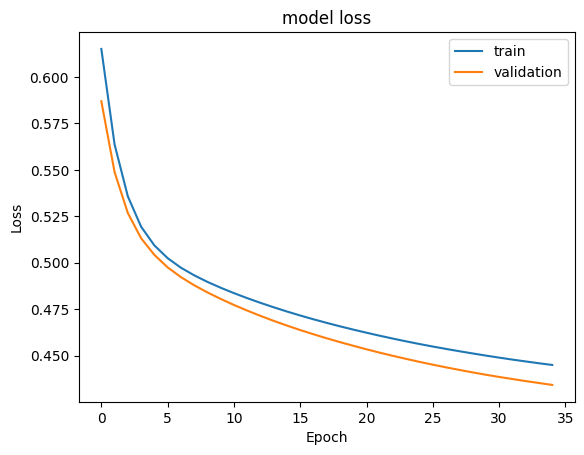

In [177]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_0.history['loss'])
plt.plot(history_0.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

Plot Train recall vs Val recall

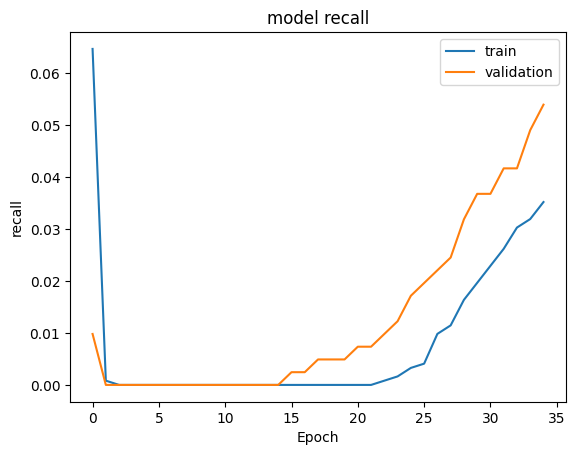

In [178]:
#Plotting Train recall vs Validation recall
plt.plot(history_0.history['recall'])
plt.plot(history_0.history['val_recall'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

In [179]:
#Predicting on Train dataset
#Sigmoid gives probabilities values from 0 to 1, thats the reason we use a threshold value to say if the prediction is True or False
#Here we are using 0.5 threshold, Any value less than 0.5 is False and greater is True

y_train_predict = model_0.predict(X_train)
y_train_predict = (y_train_predict > 0.5)
y_train_predict

188/188 [==============================] - 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [180]:
#Predicting on Val dataset
#Sigmoid gives probabilities values from 0 to 1, thats the reason we use a threshold value to say if the prediction is True or False
#Here we are using 0.5 threshold, Any value less than 0.5 is False and greater is True
y_val_predict = model_0.predict(X_val)
y_val_predict = (y_val_predict > 0.5)
y_val_predict

63/63 [==============================] - 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [181]:
#Save the Model results in the dataframe for comparison
model_name = "NN_SGD"
train_metrics.loc[model_name] = recall_score(y_train, y_train_predict)
val_metrics.loc[model_name] = recall_score(y_val, y_val_predict)
train_metrics

,Recall
NN_SGD,0.036007


Classification Report

In [182]:
#Classification report for Train dataset
cr = classification_report(y_train, y_train_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.80      0.99      0.89      4778
         1.0       0.58      0.04      0.07      1222

    accuracy                           0.80      6000
   macro avg       0.69      0.51      0.48      6000
weighted avg       0.76      0.80      0.72      6000



In [183]:
#Classification report for validation dataset
cr = classification_report(y_val, y_val_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.80      0.99      0.89      1592
         1.0       0.59      0.05      0.10       408

    accuracy                           0.80      2000
   macro avg       0.70      0.52      0.49      2000
weighted avg       0.76      0.80      0.73      2000



Confusion Matrix

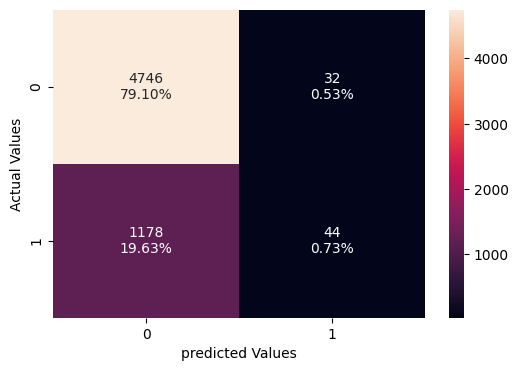

In [184]:
make_confusion_matrix(y_train, y_train_predict)

## Model Performance Improvement

### Neural Network with Adam Optimizer

In [185]:
backend.clear_session()

#Setting a seed to make sure same random generator output is generated everytime
#This is if numpy is used
np.random.seed(2)
random.seed(2)

#This is if tensorflow is used
tf.random.set_seed(2)

In [186]:
#Build Model_1

model_1 = Sequential()

#Adding first hidden layer
model_1.add(Dense(32, activation="relu", input_dim=X_train.shape[1]))
#Adding second hidden layer
model_1.add(Dense(16, activation="relu"))
#Adding output layer
model_1.add(Dense(1, activation="sigmoid"))


In [187]:
#Use Adam Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#metric = 'accuracy'
metric = tf.keras.metrics.Recall()

#Compile the mode with binary cross entropy since it is a binary classification problem
#Using Recall as the metric since we want to reduce false negatives0
model_1.compile(
optimizer=optimizer, loss='binary_crossentropy', metrics=metric)

model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                384       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 929 (3.63 KB)
Trainable params: 929 (3.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Fit the Model

In [188]:

#Fit the neural network
epoch = 50  #Increasing for Adam since it needs more epochs than SGD to converge
batch_size = 32

history_1 = model_1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epoch, batch_size=batch_size, verbose=1)

Epoch 1/50
188/188 [==============================] - 2s 4ms/step - loss: 0.4846 - recall: 0.0483 - val_loss: 0.4255 - val_recall: 0.0564
Epoch 2/50
188/188 [==============================] - 0s 2ms/step - loss: 0.4339 - recall: 0.1162 - val_loss: 0.4113 - val_recall: 0.1275
Epoch 3/50
188/188 [==============================] - 0s 2ms/step - loss: 0.4238 - recall: 0.1841 - val_loss: 0.4067 - val_recall: 0.1691
Epoch 4/50
188/188 [==============================] - 1s 3ms/step - loss: 0.4161 - recall: 0.2103 - val_loss: 0.4029 - val_recall: 0.1912
Epoch 5/50
188/188 [==============================] - 1s 4ms/step - loss: 0.4082 - recall: 0.2463 - val_loss: 0.3997 - val_recall: 0.3284
Epoch 6/50
188/188 [==============================] - 1s 4ms/step - loss: 0.4014 - recall: 0.2758 - val_loss: 0.3905 - val_recall: 0.3211
Epoch 7/50
188/188 [==============================] - 1s 4ms/step - loss: 0.3929 - recall: 0.3085 - val_loss: 0.3896 - val_recall: 0.3873
Epoch 8/50
188/188 [==============

Loss Function

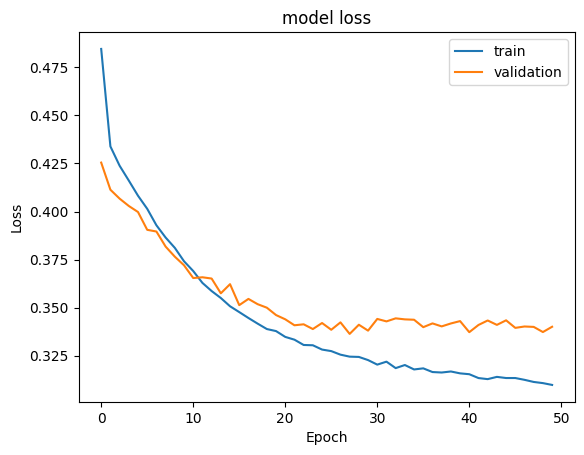

In [189]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

Recall

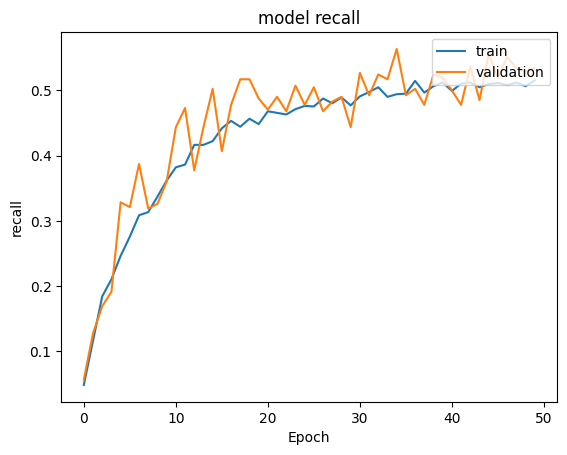

In [190]:
#Plotting Train recall vs Validation recall
plt.plot(history_1.history['recall'])
plt.plot(history_1.history['val_recall'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

In [191]:
#Predict on train data
y_train_predict = model_1.predict(X_train)
y_train_predict = (y_train_predict > 0.5)
y_train_predict

188/188 [==============================] - 1s 3ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

In [192]:
#Predict on Val data
y_val_predict = model_1.predict(X_val)
y_val_predict = (y_val_predict > 0.5)
y_val_predict

63/63 [==============================] - 0s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [False]])

In [193]:
#Save the Model results in the dataframe for comparison
model_name = "NN_Adam"
train_metrics.loc[model_name] = recall_score(y_train, y_train_predict)
val_metrics.loc[model_name] = recall_score(y_val, y_val_predict)
train_metrics

,Recall
NN_SGD,0.036007
NN_Adam,0.532733


Classification Report

In [194]:
#Classification report for Train dataset
cr = classification_report(y_train, y_train_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      4778
         1.0       0.76      0.53      0.63      1222

    accuracy                           0.87      6000
   macro avg       0.83      0.75      0.78      6000
weighted avg       0.86      0.87      0.86      6000



In [195]:
#Classification report for validation dataset
cr = classification_report(y_val, y_val_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.89      0.94      0.92      1592
         1.0       0.71      0.53      0.61       408

    accuracy                           0.86      2000
   macro avg       0.80      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000



Confusion Matrix

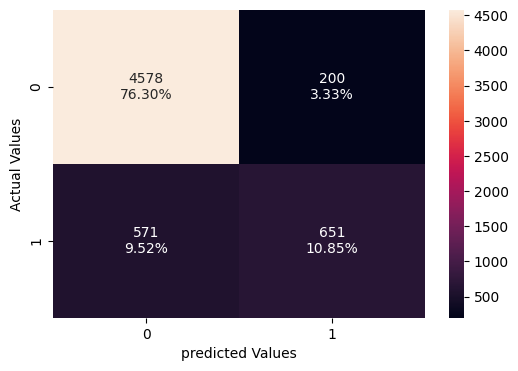

In [196]:
make_confusion_matrix(y_train, y_train_predict)

### Neural Network with Adam Optimizer and Dropout

In [197]:
backend.clear_session()

#Setting a seed to make sure same random generator output is generated everytime
#This is if numpy is used
np.random.seed(2)
random.seed(2)

#This is if tensorflow is used
tf.random.set_seed(2)

In [198]:
#Build Model_2

model_2 = Sequential()

#Adding first hidden layer
model_2.add(Dense(32, activation="relu", input_dim=X_train.shape[1]))
#Add dropout for the 1st layer
model_2.add(Dropout(0.2))

#Adding second hidden layer
model_2.add(Dense(20, activation="relu"))

#Adding 3rd hidden layer
model_2.add(Dense(16, activation="relu"))
#Add dropout for the 3rd layer
model_2.add(Dropout(0.1))

#Adding output layer
model_2.add(Dense(1, activation="sigmoid"))

In [199]:
#Use Adam Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#metric = 'accuracy'
metric = tf.keras.metrics.Recall()

#Compile the mode with binary cross entropy since it is a binary classification problem
#Using Recall as the metric since we want to reduce false negatives0
model_2.compile(
optimizer=optimizer, loss='binary_crossentropy', metrics=metric)

model_2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                384       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 20)                660       
                                                                 
 dense_2 (Dense)             (None, 16)                336       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1397 (5.46 KB)
Trainable params: 1397 (5.4

In [200]:
#Fit the neural network
epoch = 50
batch_size = 32

history_2 = model_2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epoch, batch_size=batch_size, verbose=1)

Epoch 1/50
188/188 [==============================] - 2s 4ms/step - loss: 0.4925 - recall: 0.0196 - val_loss: 0.4328 - val_recall: 0.0000e+00
Epoch 2/50
188/188 [==============================] - 1s 3ms/step - loss: 0.4518 - recall: 0.0237 - val_loss: 0.4149 - val_recall: 0.0294
Epoch 3/50
188/188 [==============================] - 1s 3ms/step - loss: 0.4441 - recall: 0.0417 - val_loss: 0.4130 - val_recall: 0.0441
Epoch 4/50
188/188 [==============================] - 1s 3ms/step - loss: 0.4326 - recall: 0.0843 - val_loss: 0.4079 - val_recall: 0.0735
Epoch 5/50
188/188 [==============================] - 1s 3ms/step - loss: 0.4301 - recall: 0.1309 - val_loss: 0.4042 - val_recall: 0.2598
Epoch 6/50
188/188 [==============================] - 1s 3ms/step - loss: 0.4257 - recall: 0.2226 - val_loss: 0.3962 - val_recall: 0.3162
Epoch 7/50
188/188 [==============================] - 1s 3ms/step - loss: 0.4179 - recall: 0.2283 - val_loss: 0.3955 - val_recall: 0.4167
Epoch 8/50
188/188 [==========

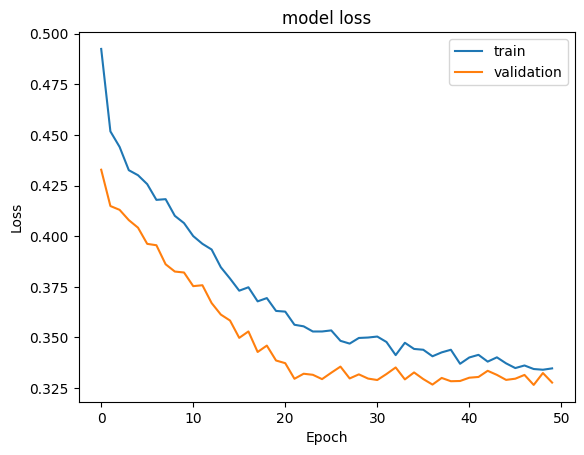

In [201]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()


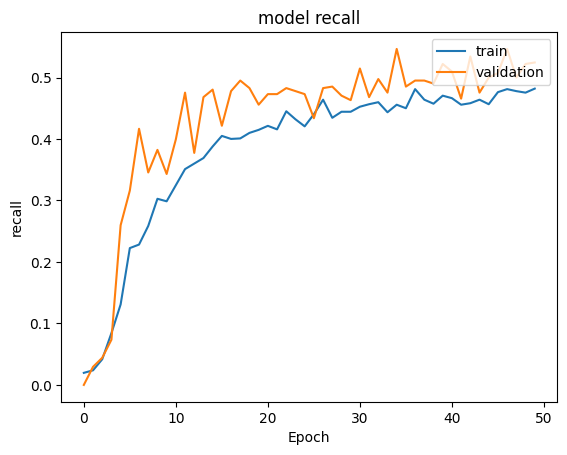

In [202]:

#Plotting Train recall vs Validation recall
plt.plot(history_2.history['recall'])
plt.plot(history_2.history['val_recall'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

In [203]:
#Predict on train data
y_train_predict = model_2.predict(X_train)
y_train_predict = (y_train_predict > 0.5)
y_train_predict

188/188 [==============================] - 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [204]:
#Predict on Val data
y_val_predict = model_2.predict(X_val)
y_val_predict = (y_val_predict > 0.5)
y_val_predict

63/63 [==============================] - 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [False]])

In [205]:
#Save the Model results in the dataframe for comparison
model_name = "NN_Adam_With_Dropout"
train_metrics.loc[model_name] = recall_score(y_train, y_train_predict)
val_metrics.loc[model_name] = recall_score(y_val, y_val_predict)
train_metrics

,Recall
NN_SGD,0.036007
NN_Adam,0.532733
NN_Adam_With_Dropout,0.515548


In [206]:
#Classification report for Train dataset
cr = classification_report(y_train, y_train_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      4778
         1.0       0.78      0.52      0.62      1222

    accuracy                           0.87      6000
   macro avg       0.83      0.74      0.77      6000
weighted avg       0.86      0.87      0.86      6000



In [207]:
#Classification report for validation dataset
cr = classification_report(y_val, y_val_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      1592
         1.0       0.78      0.52      0.63       408

    accuracy                           0.87      2000
   macro avg       0.83      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



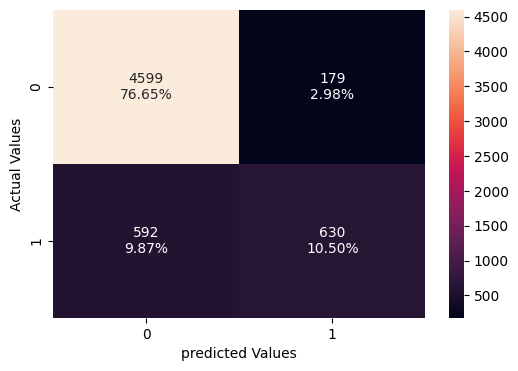

In [208]:
make_confusion_matrix(y_train, y_train_predict)

### Neural Network with Balanced Data (by applying SMOTE) and SGD Optimizer

In [209]:
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print('After Over Sampling, the shape of train_X: {}'.format(X_train_over.shape))
print('After Over Sampling, the shape of train_y: {} \n'.format(y_train_over.shape))

After Over Sampling, the shape of train_X: (9556, 11)
After Over Sampling, the shape of train_y: (9556,) 



In [210]:
backend.clear_session()

#Setting a seed to make sure same random generator output is generated everytime
#This is if numpy is used
np.random.seed(2)
random.seed(2)

#This is if tensorflow is used
tf.random.set_seed(2)

In [211]:
#Build Model_3

model_3 = Sequential()

#Adding first hidden layer
model_3.add(Dense(64, activation="relu", input_dim=X_train_over.shape[1]))

#Adding second hidden layer
model_3.add(Dense(32, activation="relu"))
#Adding output layer
model_3.add(Dense(1, activation="sigmoid"))

In [212]:
#Use SGD optimizer
optimizer = tf.keras.optimizers.SGD(0.001)

#metric = 'accuracy'
metric = tf.keras.metrics.Recall()

#Compile the mode with binary cross entropy since it is a binary classification problem
#Using Recall as the metric since we want to reduce false negatives
model_3.compile(
optimizer=optimizer, loss='binary_crossentropy', metrics=metric)

model_0.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2881 (11.25 KB)
Trainable params: 2881 (11.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [213]:
  #Fit the neural network
epoch = 35
batch_size = 32

history_3 = model_3.fit(X_train_over, y_train_over, validation_data=(X_val, y_val), epochs=epoch, batch_size=batch_size, verbose=1)

Epoch 1/35
299/299 [==============================] - 1s 3ms/step - loss: 0.7050 - recall: 0.2746 - val_loss: 0.6685 - val_recall: 0.3603
Epoch 2/35
299/299 [==============================] - 1s 2ms/step - loss: 0.6910 - recall: 0.4270 - val_loss: 0.6705 - val_recall: 0.4681
Epoch 3/35
299/299 [==============================] - 1s 2ms/step - loss: 0.6802 - recall: 0.5088 - val_loss: 0.6683 - val_recall: 0.5270
Epoch 4/35
299/299 [==============================] - 1s 2ms/step - loss: 0.6711 - recall: 0.5624 - val_loss: 0.6630 - val_recall: 0.5613
Epoch 5/35
299/299 [==============================] - 1s 2ms/step - loss: 0.6629 - recall: 0.5898 - val_loss: 0.6578 - val_recall: 0.6054
Epoch 6/35
299/299 [==============================] - 1s 2ms/step - loss: 0.6555 - recall: 0.6101 - val_loss: 0.6526 - val_recall: 0.6201
Epoch 7/35
299/299 [==============================] - 1s 3ms/step - loss: 0.6486 - recall: 0.6300 - val_loss: 0.6455 - val_recall: 0.6324
Epoch 8/35
299/299 [==============

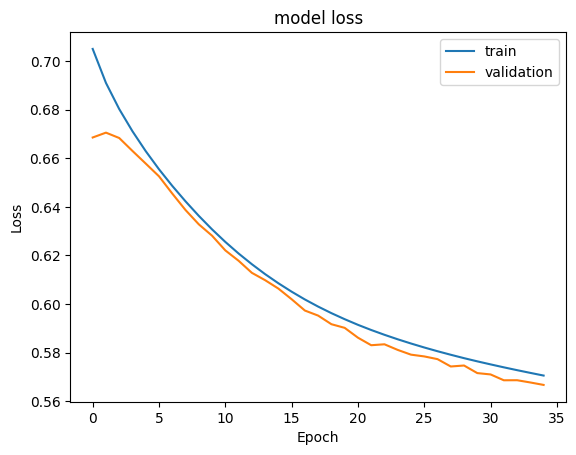

In [214]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

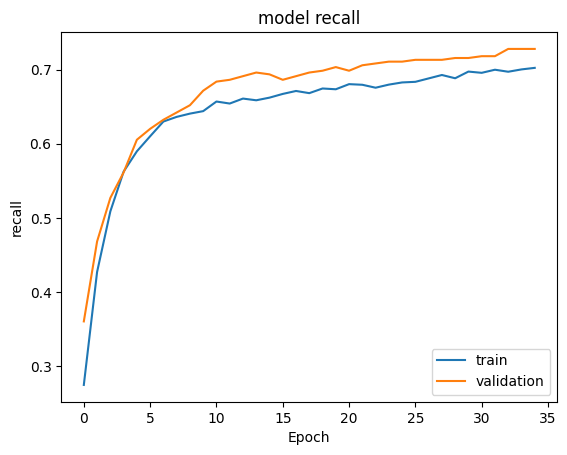

In [215]:
#Plotting Train recall vs Validation recall
plt.plot(history_3.history['recall'])
plt.plot(history_3.history['val_recall'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.show()

In [216]:
#Predict on train data
y_train_predict = model_3.predict(X_train_over)
y_train_predict = (y_train_predict > 0.5)
y_train_predict

299/299 [==============================] - 0s 1ms/step


array([[ True],
       [False],
       [ True],
       ...,
       [ True],
       [False],
       [False]])

In [217]:
#Predict on Val data
#Sigmoid gives probabilities values from 0 to 1, thats the reason we use a threshold value to say if the prediction is True or False
#Here we are using 0.5 threshold, Any value less than 0.5 is False and greater is True
y_val_predict = model_3.predict(X_val)
print(y_val_predict)
y_val_predict = (y_val_predict > 0.5)
y_val_predict

63/63 [==============================] - 0s 2ms/step
[[0.43492925]
 [0.45544606]
 [0.28843933]
 ...
 [0.74621683]
 [0.47489083]
 [0.45539832]]


array([[False],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [False]])

In [218]:
#Save the Model results in the dataframe for comparison
model_name = "NN_SGD_With_SMOTE OverSampling"
train_metrics.loc[model_name] = recall_score(y_train_over, y_train_predict)
val_metrics.loc[model_name] = recall_score(y_val, y_val_predict)
train_metrics

,Recall
NN_SGD,0.036007
NN_Adam,0.532733
NN_Adam_With_Dropout,0.515548
NN_SGD_With_SMOTE OverSampling,0.701967


In [219]:
#Classification report for Train dataset
cr = classification_report(y_train_over, y_train_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.71      0.73      0.72      4778
         1.0       0.72      0.70      0.71      4778

    accuracy                           0.72      9556
   macro avg       0.72      0.72      0.72      9556
weighted avg       0.72      0.72      0.72      9556



In [220]:
#Classification report for validation dataset
cr = classification_report(y_val, y_val_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1592
         1.0       0.41      0.73      0.52       408

    accuracy                           0.73      2000
   macro avg       0.66      0.73      0.67      2000
weighted avg       0.81      0.73      0.75      2000



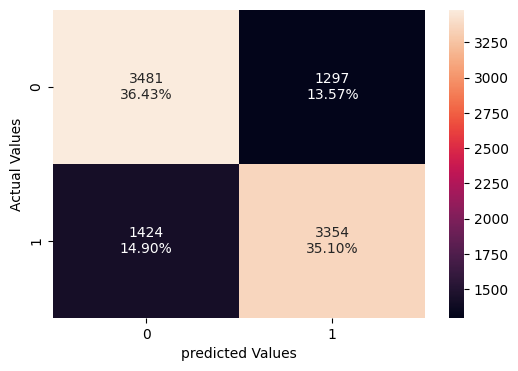

In [221]:

make_confusion_matrix(y_train_over, y_train_predict)

### Neural Network with Balanced Data (by applying SMOTE) and Adam Optimizer

In [222]:
backend.clear_session()

#Setting a seed to make sure same random generator output is generated everytime
#This is if numpy is used
np.random.seed(2)
random.seed(2)

#This is if tensorflow is used
tf.random.set_seed(2)

In [223]:
#Build Model_4

model_4 = Sequential()

#Adding first hidden layer
model_4.add(Dense(32, activation="relu", input_dim=X_train_over.shape[1]))

#Adding second hidden layer
model_4.add(Dense(16, activation="relu"))
#Adding output layer
model_4.add(Dense(1, activation="sigmoid"))

In [224]:
#Use Adam Optimizer
optimizer = tf.keras.optimizers.Adam(0.001)

#metric = 'accuracy'
metric = tf.keras.metrics.Recall()

In [225]:
#Compile the mode with binary cross entropy since it is a binary classification problem
#Using Recall as the metric since we want to reduce false negatives
model_4.compile(
optimizer=optimizer, loss='binary_crossentropy', metrics=metric)

model_4.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                384       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 929 (3.63 KB)
Trainable params: 929 (3.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [226]:
#Fit the neural network
epoch = 100
batch_size = 32

history_4 = model_4.fit(X_train_over, y_train_over, validation_data=(X_val, y_val), epochs=epoch, batch_size=batch_size, verbose=1)

Epoch 1/100
299/299 [==============================] - 2s 5ms/step - loss: 0.6051 - recall: 0.6660 - val_loss: 0.5811 - val_recall: 0.7721
Epoch 2/100
299/299 [==============================] - 1s 4ms/step - loss: 0.5569 - recall: 0.7398 - val_loss: 0.5268 - val_recall: 0.7475
Epoch 3/100
299/299 [==============================] - 1s 3ms/step - loss: 0.5311 - recall: 0.7568 - val_loss: 0.5448 - val_recall: 0.7819
Epoch 4/100
299/299 [==============================] - 1s 3ms/step - loss: 0.5113 - recall: 0.7604 - val_loss: 0.4997 - val_recall: 0.7451
Epoch 5/100
299/299 [==============================] - 1s 2ms/step - loss: 0.4967 - recall: 0.7578 - val_loss: 0.5223 - val_recall: 0.7770
Epoch 6/100
299/299 [==============================] - 1s 2ms/step - loss: 0.4832 - recall: 0.7675 - val_loss: 0.4930 - val_recall: 0.7647
Epoch 7/100
299/299 [==============================] - 1s 2ms/step - loss: 0.4739 - recall: 0.7779 - val_loss: 0.4783 - val_recall: 0.7574
Epoch 8/100
299/299 [======

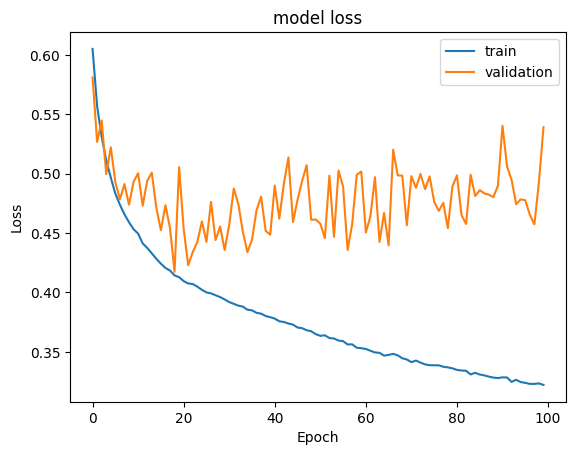

In [227]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

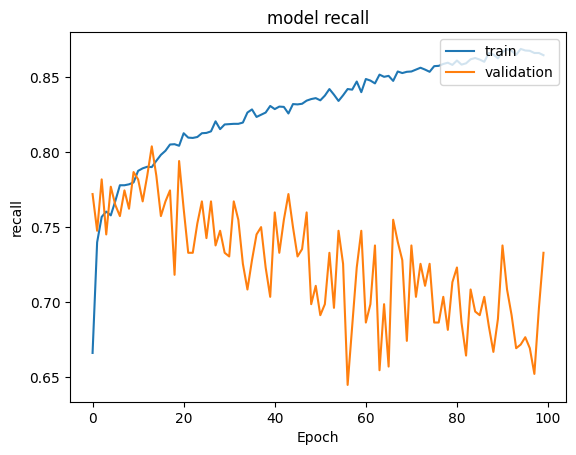

In [228]:
#Plotting Train recall vs Validation recall
plt.plot(history_4.history['recall'])
plt.plot(history_4.history['val_recall'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

In [229]:
#Predict on train data
y_train_predict = model_4.predict(X_train_over)
y_train_predict = (y_train_predict > 0.5)
y_train_predict

299/299 [==============================] - 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [ True],
       [ True],
       [ True]])

In [230]:
#Predict on Val data
y_val_predict = model_0.predict(X_val)
y_val_predict = (y_val_predict > 0.5)
y_val_predict

63/63 [==============================] - 0s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [231]:
#Save the Model results in the dataframe for comparison
model_name = "NN_Adam_with_SMOTE OverSampling"
train_metrics.loc[model_name] = recall_score(y_train_over, y_train_predict)
val_metrics.loc[model_name] = recall_score(y_val, y_val_predict)
train_metrics

,Recall
NN_SGD,0.036007
NN_Adam,0.532733
NN_Adam_With_Dropout,0.515548
NN_SGD_With_SMOTE OverSampling,0.701967
NN_Adam_with_SMOTE OverSampling,0.904353


In [232]:
#Classification report for Train dataset
cr = classification_report(y_train_over, y_train_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.90      0.83      0.86      4778
         1.0       0.84      0.90      0.87      4778

    accuracy                           0.87      9556
   macro avg       0.87      0.87      0.87      9556
weighted avg       0.87      0.87      0.87      9556



In [233]:
#Classification report for validation dataset
cr = classification_report(y_val, y_val_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.80      0.99      0.89      1592
         1.0       0.59      0.05      0.10       408

    accuracy                           0.80      2000
   macro avg       0.70      0.52      0.49      2000
weighted avg       0.76      0.80      0.73      2000



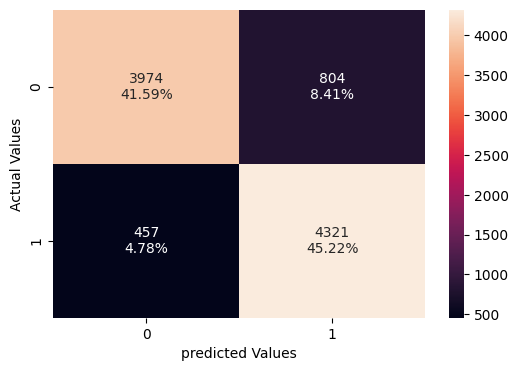

In [234]:
make_confusion_matrix(y_train_over, y_train_predict)

### Neural Network with Balanced Data (by applying SMOTE), Adam Optimizer, and Dropout

In [235]:
backend.clear_session()
#Setting a seed to make sure same random generator output is generated everytime
#This is if numpy is used
np.random.seed(2)
random.seed(2)

In [236]:
#Build Model_5

model_5 = Sequential()

#Adding first hidden layer
model_5.add(Dense(32, activation="relu", input_dim=X_train_over.shape[1]))
#Add dropout for the 1st layer
model_5.add(Dropout(0.2))

#Adding second hidden layer
model_5.add(Dense(16, activation="relu"))

#Adding 3rd hidden layer
model_5.add(Dense(8, activation="relu"))
#Add dropout for the 3rd layer
model_5.add(Dropout(0.1))

#Adding output layer
model_5.add(Dense(1, activation="sigmoid"))

In [237]:
optimizer = tf.keras.optimizers.Adam(0.001)

#metric = 'accuracy'
metric = tf.keras.metrics.Recall()

#Compile the mode with binary cross entropy since it is a binary classification problem
#Using Recall as the metric since we want to reduce false negatives
model_5.compile(
optimizer=optimizer, loss='binary_crossentropy', metrics=metric)

model_5.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                384       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 8)                 136       
                                                                 
 dropout_1 (Dropout)         (None, 8)                 0         
                                                                 
 dense_3 (Dense)             (None, 1)                 9         
                                                                 
Total params: 1057 (4.13 KB)
Trainable params: 1057 (4.1

In [238]:
#Fit the neural network
epoch =50
batch_size = 32


history_5 = model_5.fit(X_train_over, y_train_over, validation_data=(X_val, y_val), epochs=epoch, batch_size=batch_size, verbose=1)

Epoch 1/50
299/299 [==============================] - 3s 5ms/step - loss: 0.6355 - recall: 0.7001 - val_loss: 0.5740 - val_recall: 0.7426
Epoch 2/50
299/299 [==============================] - 1s 4ms/step - loss: 0.5881 - recall: 0.7365 - val_loss: 0.5375 - val_recall: 0.7279
Epoch 3/50
299/299 [==============================] - 1s 3ms/step - loss: 0.5810 - recall: 0.7403 - val_loss: 0.5676 - val_recall: 0.7794
Epoch 4/50
299/299 [==============================] - 1s 3ms/step - loss: 0.5671 - recall: 0.7403 - val_loss: 0.5354 - val_recall: 0.7500
Epoch 5/50
299/299 [==============================] - 1s 3ms/step - loss: 0.5579 - recall: 0.7325 - val_loss: 0.5478 - val_recall: 0.7819
Epoch 6/50
299/299 [==============================] - 1s 3ms/step - loss: 0.5475 - recall: 0.7378 - val_loss: 0.5236 - val_recall: 0.7451
Epoch 7/50
299/299 [==============================] - 1s 3ms/step - loss: 0.5349 - recall: 0.7520 - val_loss: 0.5095 - val_recall: 0.7377
Epoch 8/50
299/299 [==============

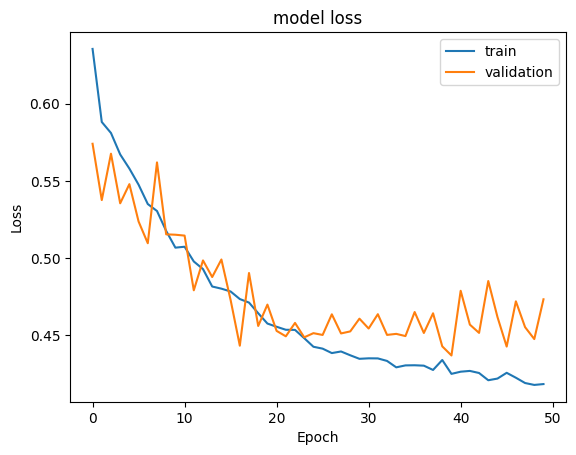

In [239]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_5.history['loss'])
plt.plot(history_5.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

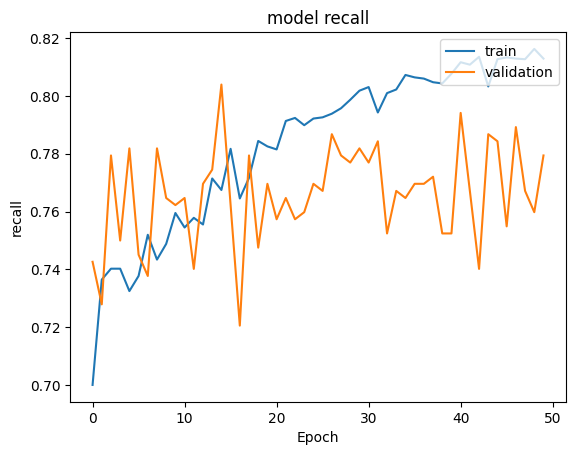

In [240]:
#Plotting Train recall vs Validation recall
plt.plot(history_5.history['recall'])
plt.plot(history_5.history['val_recall'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

In [241]:
#Predict on train data
y_train_predict = model_0.predict(X_train_over)
y_train_predict = (y_train_predict > 0.5)
y_train_predict

299/299 [==============================] - 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [242]:
#Predict on Val data
y_val_predict = model_0.predict(X_val)
y_val_predict = (y_val_predict > 0.5)
y_val_predict

63/63 [==============================] - 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [243]:
#Save the Model results in the dataframe for comparison
model_name = "NN_Adam_Dropout_with_SMOTE sampling"
train_metrics.loc[model_name] = recall_score(y_train_over, y_train_predict)
val_metrics.loc[model_name] = recall_score(y_val, y_val_predict)
train_metrics

,Recall
NN_SGD,0.036007
NN_Adam,0.532733
NN_Adam_With_Dropout,0.515548
NN_SGD_With_SMOTE OverSampling,0.701967
NN_Adam_with_SMOTE OverSampling,0.904353
NN_Adam_Dropout_with_SMOTE sampling,0.034324


In [244]:
#Classification report for Train dataset
cr = classification_report(y_train_over, y_train_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.51      0.99      0.67      4778
         1.0       0.84      0.03      0.07      4778

    accuracy                           0.51      9556
   macro avg       0.67      0.51      0.37      9556
weighted avg       0.67      0.51      0.37      9556



In [245]:
#Classification report for validation dataset
cr = classification_report(y_val, y_val_predict)
print(cr)

              precision    recall  f1-score   support

         0.0       0.80      0.99      0.89      1592
         1.0       0.59      0.05      0.10       408

    accuracy                           0.80      2000
   macro avg       0.70      0.52      0.49      2000
weighted avg       0.76      0.80      0.73      2000



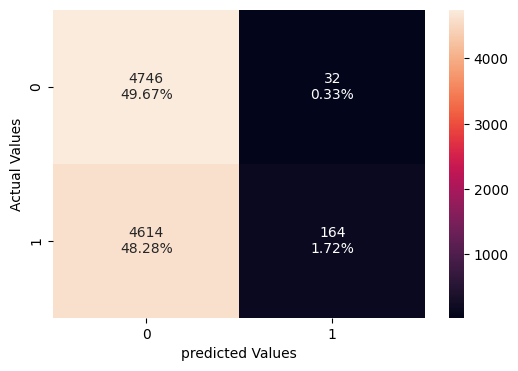

In [246]:
make_confusion_matrix(y_train_over, y_train_predict)

## Model Performance Comparison and Final Model Selection

In [247]:
train_metrics

,Recall
NN_SGD,0.036007
NN_Adam,0.532733
NN_Adam_With_Dropout,0.515548
NN_SGD_With_SMOTE OverSampling,0.701967
NN_Adam_with_SMOTE OverSampling,0.904353
NN_Adam_Dropout_with_SMOTE sampling,0.034324


In [248]:
val_metrics

,Recall
NN_SGD,0.053922
NN_Adam,0.534314
NN_Adam_With_Dropout,0.524510
NN_SGD_With_SMOTE OverSampling,0.727941
NN_Adam_with_SMOTE OverSampling,0.053922
NN_Adam_Dropout_with_SMOTE sampling,0.053922


In [249]:
train_metrics - val_metrics

,Recall
NN_SGD,-0.017915
NN_Adam,-0.001581
NN_Adam_With_Dropout,-0.008962
NN_SGD_With_SMOTE OverSampling,-0.025974
NN_Adam_with_SMOTE OverSampling,0.850432
NN_Adam_Dropout_with_SMOTE sampling,-0.019598


Neural Network with SGD optimizer with oversampling performed better.

In [250]:
X_test = np.asarray(X_test).astype(np.float32)
y_test = np.asarray(y_test).astype(np.float32)

y_test_pred = model_3.predict(X_test)    ## Complete the code to specify the best model
y_test_pred = (y_test_pred > 0.5)
print(y_test_pred)

63/63 [==============================] - 0s 1ms/step
[[False]
 [False]
 [ True]
 ...
 [ True]
 [False]
 [False]]


In [251]:
#Classification Report
cr=classification_report(y_test,y_test_pred)
print(cr)

              precision    recall  f1-score   support

         0.0       0.90      0.73      0.80      1593
         1.0       0.39      0.69      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



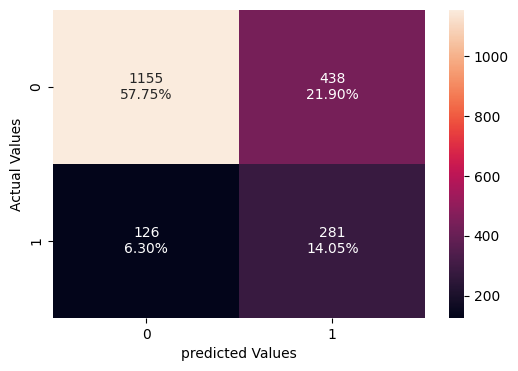

In [252]:
#Calculating the confusion matrix
make_confusion_matrix(y_test,y_test_pred)

## Actionable Insights and Business Recommendations

There are more male customers but more female customers exited compared to male customers.

Customers with less transactional activity existed compared with the ones with more activity.

Tenure and having a credit card didn't have an impact on customer churn out.

Most of the customers exited had just 1 product.

Bank should plan incentives to female customers and also sell more products to retain customers

Bank should proactively work with customers with less activity and get a feedback on customer satisfaction






<font size=6 color='blue'>Power Ahead</font>
___